In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
#!pip install rouge_score
#!pip install pandas scikit-learn
!pip install git+https://github.com/google-deepmind/recurrentgemma.git

  Cloning https://github.com/google-deepmind/recurrentgemma.git to /tmp/pip-req-build-2_0qutyb
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/recurrentgemma.git /tmp/pip-req-build-2_0qutyb
  Resolved https://github.com/google-deepmind/recurrentgemma.git to commit c70d42d9fecfe8b9f27e8c70bd098075c90123ec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.7 MB/s eta 0:00:00
  Created wheel for recurrentgemma: filename=recurrentgemma-1.0.0-py3-none-any.whl size=87747 sha256=6a049a1d4b5bd2470335dbc69c50559d8a6763ec1c3c02315d2bbfa3c34815ef
  Stored in directory: /tmp/pip-ephem-wheel-cache-molo57tx/wheels/88/00/4c/fe9af087e69e42f88b7aa1e14c161a0b0d077eb34f7951bcb7
Successfully built recurrentgemma
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.4
    Uninstalling typeguard-4.4

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

google_recurrentgemma_flax_2b_it_1_path = kagglehub.model_download('google/recurrentgemma/Flax/2b-it/1')

print('Data source import complete.')


Data source import complete.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.model_download("google/recurrentgemma/flax/2b")

print("Path to model files:", path)

Path to model files: /kaggle/input/recurrentgemma/flax/2b/1


In [ ]:
import jax
print(f"JAX version: {jax.__version__}")

JAX version: 0.7.2


In [ ]:
# @title Python imports
import pathlib
from typing import Any
import enum
import functools

# We import JAX and some related packages.
import chex
import jax
import jax.numpy as jnp
import optax

# We will use tensorflow to handle the dataset
import tensorflow as tf
import tensorflow_datasets as tfds

# Finally, we import Recurrentgemma.
import sentencepiece as spm
from recurrentgemma import jax as recurrentgemma

In [ ]:
VARIANT = '2b' # @param ['2b', '2b-it', '9b', '9b-it'] {type:"string"}
# weights_dir = kagglehub.model_download(f'google/recurrentgemma/Flax/{VARIANT}')

weights_dir = pathlib.Path(f"/root/.cache/kagglehub/models/google/recurrentgemma/flax/{VARIANT}/1")
ckpt_path = weights_dir / VARIANT
vocab_path = weights_dir / 'tokenizer.model'
preset = recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1

In [ ]:
VARIANT = '2b' # @param ['2b', '2b-it', '9b', '9b-it'] {type:"string"}
# weights_dir = kagglehub.model_download(f'google/recurrentgemma/Flax/{VARIANT}')

weights_dir = pathlib.Path(f"/kaggle/input/recurrentgemma/flax/{VARIANT}/1")
ckpt_path = weights_dir / VARIANT
vocab_path = weights_dir / 'tokenizer.model'
preset = recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1

NameError: name 'recurrentgemma' is not defined

In [ ]:
# Load parameters
params =  recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(params, preset=preset)
model = recurrentgemma.Griffin(model_config)

PREPARE DATASET

In [ ]:
import pandas as pd

# Memuat dataset dari CSV
df = pd.read_csv('/content/cleaned_dataset_kategori_checkpoint.csv')  # Ganti dengan path file dataset kamu

# Menampilkan 5 baris pertama dari dataset
df.head()


,title,content,category,summary,kategori_baru
0,Cara Bayar First Media lewat m-Banking BCA den...,cara bayar first media dapat dilakukan melalui...,Money,artikel ini menjelaskan berbagai metode pembay...,Ekonomi & Bisnis
1,Simak 6 Tips Mengumpulkan Dana Darurat dari Pe...,dana darurat adalah dana yang disisihkan atau ...,Money,artikel ini membahas pentingnya dana darurat u...,Ekonomi & Bisnis
2,7 Ide Resolusi Tahun Baru 2024 buat Keluarga,tahun baru adalah waktu untuk membuat resolusi...,Lifestyle,artikel ini menyajikan beragam ide resolusi ta...,Gaya Hidup & Hiburan
3,"Prestasi Olahraga Indonesia Meningkat, Bekal M...","ketua komite olimpiade (noc) indonesia, raja s...",Bola,"ketua noc indonesia, raja sapta oktohari, mela...",Olahraga
4,Babak 12 Besar Liga 2 2023-2024: PSIM Dikepung...,kompetisi liga 2 2023-2024 telah memasuki baba...,Bola,babak 12 besar liga 2 2023-2024 akan dimulai p...,Olahraga


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Memuat dataset utama
df = pd.read_csv('cleaned_dataset_kategori_checkpoint.csv')

# Nama folder untuk menyimpan file split
output_folder = 'Split_data'

# Menentukan kategori target untuk data latih dan validasi
target_categories = [
    'Ekonomi & Bisnis',
    'Gaya Hidup & Hiburan',
    'Olahraga',
    'Politik Nasional',
    'Hukum & Kriminalitas'
]

# --- 1. Membuat kumpulan 10.000 data untuk Pelatihan dan Validasi ---
train_val_pool_dfs = []
for category in target_categories:
    # Filter dan ambil sampel 2000 untuk setiap kategori
    category_df = df[df['kategori_baru'] == category].sample(n=2000, random_state=42)
    train_val_pool_dfs.append(category_df)

# Gabungkan menjadi satu DataFrame berisi 10.000 baris
df_train_val_pool = pd.concat(train_val_pool_dfs)

# --- 2. Membuat Data Uji (dari data yang TIDAK ADA di kumpulan latih/validasi) ---
# Ambil sisa data dengan membuang indeks dari 10.000 data yang sudah dipilih
df_remaining = df.drop(df_train_val_pool.index)

# Dari sisa data, ambil 50 sampel dari 5 kategori target
df_remaining_target = df_remaining[df_remaining['kategori_baru'].isin(target_categories)]
test_from_target = df_remaining_target.sample(n=50, random_state=42)

# Dari sisa data, ambil 50 sampel dari kategori LAINNYA
df_remaining_other = df_remaining[~df_remaining['kategori_baru'].isin(target_categories)]
test_from_other = df_remaining_other.sample(n=50, random_state=42)

# Gabungkan untuk membuat data uji final berisi 100 baris
df_test = pd.concat([test_from_target, test_from_other])

# --- 3. Bagi kumpulan 10.000 data menjadi Latih (80%) dan Validasi (20%) ---
# Gunakan 'stratify' untuk memastikan rasio 80/20 terjaga di setiap kategori
y = df_train_val_pool['kategori_baru']
df_train, df_validation = train_test_split(
    df_train_val_pool,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=y
)

# --- 4. Tampilkan ukuran, acak, dan simpan dataset final ---
# Acak dan reset indeks sebelum menyimpan
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_validation = df_validation.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

# Membuat folder output jika belum ada
os.makedirs(output_folder, exist_ok=True)
print(f"Folder '{output_folder}' telah disiapkan.")

# Menentukan path lengkap untuk setiap file
train_file_path = os.path.join(output_folder, 'train_data.csv')
val_file_path = os.path.join(output_folder, 'val_data.csv')
test_file_path = os.path.join(output_folder, 'test_data.csv')

# Menyimpan file ke dalam folder yang ditentukan
df_train.to_csv(train_file_path, index=False)
df_validation.to_csv(val_file_path, index=False)
df_test.to_csv(test_file_path, index=False)

print(f"File berhasil disimpan di dalam folder '{output_folder}'.")

# Menampilkan ukuran setiap dataset
print("\n--- Ukuran Setiap Split Data ---")
print(f"Jumlah data Latih (Train): {len(df_train)} baris")
print(f"Jumlah data Validasi (Validation): {len(df_validation)} baris")
print(f"Jumlah data Uji (Test): {len(df_test)} baris")
print("---------------------------------")

Folder 'Split_data' telah disiapkan.
File berhasil disimpan di dalam folder 'Split_data'.

--- Ukuran Setiap Split Data ---
Jumlah data Latih (Train): 8000 baris
Jumlah data Validasi (Validation): 2000 baris
Jumlah data Uji (Test): 100 baris
---------------------------------


In [ ]:
import tensorflow_datasets as tfds
import pandas as pd
import os

class KompasSummarizationDataset(tfds.core.GeneratorBasedBuilder):
    """Dataset for Kompas news articles, with title, content, and category, for summarization."""

    VERSION = tfds.core.Version("1.0.0")

    def _info(self):
        """Returns dataset metadata, including features and labels."""
        return tfds.core.DatasetInfo(
            builder=self,
            description="Kompas news dataset for summarization task (content to summary).",
            features=tfds.features.FeaturesDict({
                'content': tfds.features.Text(),  # Input: content of the article to summarize
                'summary': tfds.features.Text(),  # Output: the summary of the article
            }),
            supervised_keys=("content", "summary"),  # ('input', 'label') pair for summarization
            homepage="http://www.kompas.com",
        )

    def _split_generators(self, dl_manager):
        """Split the dataset into train, test, and validation."""
        data_dir = '/content/Split_data'  # The directory where your data files are located

        return [
            tfds.core.SplitGenerator(
                name=tfds.Split.TRAIN,
                gen_kwargs={"file_path": os.path.join(data_dir, "/content/Split_data/train_data.csv")}
            ),
            tfds.core.SplitGenerator(
                name=tfds.Split.TEST,
                gen_kwargs={"file_path": os.path.join(data_dir, "/content/Split_data/test_data.csv")}
            ),
            tfds.core.SplitGenerator(
                name=tfds.Split.VALIDATION,
                gen_kwargs={"file_path": os.path.join(data_dir, "/content/Split_data/val_data.csv")}
            ),
        ]

    def _generate_examples(self, file_path):
        """Read the dataset and yield examples."""
        df = pd.read_csv(file_path)  # Read the CSV file

        # Iterate through the dataset and yield each example
        for idx, row in df.iterrows():
            yield idx, {
                'content': row['content'],  # The input text (article content)
                'summary': row['summary'],    # The summary (using title as summary for simplicity, replace with actual summaries)
            }


In [ ]:
import tensorflow_datasets as tfds

# Memuat dataset kustom
dataset, info = tfds.load("kompas_summarization_dataset", with_info=True, as_supervised=True)

# Mengakses dataset train
train_dataset = dataset['train']
for example in train_dataset.take(1):  # Ambil satu batch
    print(example)


Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kompas_summarization_dataset/incomplete.2QO9N5_1.0.0/kompas_summarization_…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kompas_summarization_dataset/incomplete.2QO9N5_1.0.0/kompas_summarization_…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kompas_summarization_dataset/incomplete.2QO9N5_1.0.0/kompas_summarization_…

Dataset kompas_summarization_dataset downloaded and prepared to /root/tensorflow_datasets/kompas_summarization_dataset/1.0.0. Subsequent calls will reuse this data.
(<tf.Tensor: shape=(), dtype=string, numpy=b'kulon progo, seorang lanjut usia ditemukan meninggal dunia di dalam rumahnya pada padukuhan sewugalur,\xc2\xa0 kalurahan karangsewu, kapanewon galur, kabupaten kulon progo, daerah istimewa yogyakarta.\xc2\xa0warga mengenal lansia itu sebagai murtadho (82), dulunya petani.\xc2\xa0lansia itu tergeletak di lantai dalam keadaan sudah tidak bernyawa.\xe2\x80\x9cwarga mendapati kondisi tetangganya itu sekitar pukul 10.00 wib,\xe2\x80\x9d kata kasi humas polres kulon progo ajun komisaris polisi, triatmi noviartuti (novi), lewat pesan singkat, kamis (11/1/2024).\xc2\xa0warga melapor ke dukuh (kepala dusun) sewugalur, dyan indri astuti. kabar itu cepat sampai ke warga lain sehingga berdatangan.\xc2\xa0dukuh dyan melaporkan temuan itu ke polsek galur.\xe2\x80\x9ckejadian tersebut kemudian 

In [ ]:
import tensorflow_datasets as tfds

# Memuat dataset kustom
dataset, info = tfds.load("kompas_summarization_dataset", with_info=True, as_supervised=True)

# Mengakses dataset train
train_dataset = dataset['train']

# Ambil satu contoh dari dataset untuk melihat formatnya
for example in train_dataset.take(1):  # Mengambil satu batch
    content, summary = example  # 'content' adalah input (teks berita), 'summary' adalah output (ringkasan)
    print("Content:", content.numpy())  # Menampilkan konten yang perlu diringkas
    print("Summary:", summary.numpy())  # Menampilkan ringkasan yang diinginkan


Content: b'kulon progo, seorang lanjut usia ditemukan meninggal dunia di dalam rumahnya pada padukuhan sewugalur,\xc2\xa0 kalurahan karangsewu, kapanewon galur, kabupaten kulon progo, daerah istimewa yogyakarta.\xc2\xa0warga mengenal lansia itu sebagai murtadho (82), dulunya petani.\xc2\xa0lansia itu tergeletak di lantai dalam keadaan sudah tidak bernyawa.\xe2\x80\x9cwarga mendapati kondisi tetangganya itu sekitar pukul 10.00 wib,\xe2\x80\x9d kata kasi humas polres kulon progo ajun komisaris polisi, triatmi noviartuti (novi), lewat pesan singkat, kamis (11/1/2024).\xc2\xa0warga melapor ke dukuh (kepala dusun) sewugalur, dyan indri astuti. kabar itu cepat sampai ke warga lain sehingga berdatangan.\xc2\xa0dukuh dyan melaporkan temuan itu ke polsek galur.\xe2\x80\x9ckejadian tersebut kemudian dilaporkan ke polsek galur,\xe2\x80\x9d kata novi.murtadho lansia yang hidup sendirian di rumah berdinding batu milik adiknya.murtadho sakit-sakitan dan agak pikun karena usianya. karena sakitnya, ia

In [ ]:
ds = tfds.load("kompas_summarization_dataset", split="train")
ds = ds.take(2)
ds = ds.as_numpy_iterator()
for idx, example in enumerate(ds):
  print(f'Example {idx}:')
  for key, val in example.items():
    print(f'{key}: {val.decode("utf-8")}')
  print()

Example 0:
content: kulon progo, seorang lanjut usia ditemukan meninggal dunia di dalam rumahnya pada padukuhan sewugalur,  kalurahan karangsewu, kapanewon galur, kabupaten kulon progo, daerah istimewa yogyakarta. warga mengenal lansia itu sebagai murtadho (82), dulunya petani. lansia itu tergeletak di lantai dalam keadaan sudah tidak bernyawa.“warga mendapati kondisi tetangganya itu sekitar pukul 10.00 wib,” kata kasi humas polres kulon progo ajun komisaris polisi, triatmi noviartuti (novi), lewat pesan singkat, kamis (11/1/2024). warga melapor ke dukuh (kepala dusun) sewugalur, dyan indri astuti. kabar itu cepat sampai ke warga lain sehingga berdatangan. dukuh dyan melaporkan temuan itu ke polsek galur.“kejadian tersebut kemudian dilaporkan ke polsek galur,” kata novi.murtadho lansia yang hidup sendirian di rumah berdinding batu milik adiknya.murtadho sakit-sakitan dan agak pikun karena usianya. karena sakitnya, ia lebih banyak duduk dan sulit berjalan.  dukuh dyan menceritakan, murt

TOKENIZER

In [ ]:
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))

True

In [ ]:
class GriffinTokenizer:
  """A custom wrapper around a SentencePieceProcessor."""

  def __init__(self, spm_processor: spm.SentencePieceProcessor):
    self._spm_processor = spm_processor

  @property
  def pad_id(self) -> int:
    """Fast access to the pad ID."""
    return self._spm_processor.pad_id()

  def tokenize(
      self,
      example: str | bytes,
      prefix: str = '',
      suffix: str = '',
      add_eos: bool = True,
  ) -> jax.Array:
    """
    A tokenization function.

    Args:
      example: Input string to tokenize.
      prefix:  Prefix to add to the input string.
      suffix:  Suffix to add to the input string.
      add_eos: If True, add an end of sentence token at the end of the output
               sequence.
    Returns:
      Tokens corresponding to the input string.
    """
    int_list = [self._spm_processor.bos_id()]
    int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos:
      int_list.append(self._spm_processor.eos_id())

    return jnp.array(int_list, dtype=jnp.int32)

  def tokenize_tf_op(
      self,
      str_tensor: tf.Tensor,
      prefix: str = '',
      suffix: str = '',
      add_eos: bool = True,
  ) -> tf.Tensor:
    """A TensforFlow operator for the `tokenize` function."""
    encoded = tf.numpy_function(
        self.tokenize,
        [str_tensor, prefix, suffix, add_eos],
        tf.int32)
    encoded.set_shape([None])
    return encoded

  def to_string(self, tokens: jax.Array) -> str:
    """Convert an array of tokens to a string."""
    return self._spm_processor.EncodeIds(tokens.tolist())

In [ ]:
def tokenize_source(tokenizer, example: tf.Tensor):
  return tokenizer.tokenize_tf_op(
      example,
      prefix='Write a comprehensive and concise abstract summary of the following news text in one paragraph:\n\n',
      suffix='\n',
      add_eos=False
  )
def tokenize_destination(tokenizer, example: tf.Tensor):
    return tokenizer.tokenize_tf_op(
        example,
        prefix='',  # Tidak perlu prefix untuk label
        suffix='\n',  # Akhiran untuk memisahkan, bisa tambahkan baris baru jika perlu
        add_eos=True  # Menambahkan EOS di akhir label (ringkasan)
    )

tokenizer = GriffinTokenizer(vocab)

ds = tfds.load("kompas_summarization_dataset",split="train")
ds = ds.take(2)
ds = ds.map(lambda x: {
    'content': tokenize_source(tokenizer, x['content']),
    'summary': tokenize_destination(tokenizer, x['summary'])
  })
ds = ds.as_numpy_iterator()

for idx, example in enumerate(ds):
  print(f'Example {idx}:')
  for key, val in example.items():
    print(f'{key}: {val}')
  print()

Example 0:
content: [     2   5559    476  17540    578  66004   9949  13367    576    573
   2412   3905   2793    575    974  16957 235292    109  40186    477
    656   1052 235269  33740  67109  82642  86871  65096  34067    751
   7168 214040   8083   7174  19913   2990  36125  29618    525 235269
 236338  11172 111793   8386    754    497  27009 235269 117824 202848
   7128    525 235269 151818  21327    477    656   1052 235269  49154
 180477  35999  95456 235265 236338   3216   1012 163278   7607   3394
   7611  12865   8271  15779    572    591 235321 235284    823  30174
  26784 162159 235265 236338   1033   3394   7611   1390  35105   9306
    751  95414   7168  86172  16249   7619   2747   1283   8983  21897
   3216   1012  15808 150520  57407  33593  70730   2194   7611  38678
  85789 235248 235274 235276 235265 235276 235276    613 235268   2316
  20181 107889   2561    508   4374    624  21327    477    656   1052
   8572    549 205398  21985  98795 235269   1647    482 

In [ ]:
@chex.dataclass(frozen=True)
class TrainingInput:
  # Input tokens given to the model
  input_tokens: jax.Array

  # A mask that determines which tokens contribute to the target loss
  # calculation.
  target_mask: jax.Array

class DatasetSplit(enum.Enum):
  TRAIN = 'train'
  VALIDATION = 'validation'


class DatasetBuilder:
  """Data loader for dataset."""

  N_ITEMS = {DatasetSplit.TRAIN: 8_000  , DatasetSplit.VALIDATION: 2_000 }

  BUFFER_SIZE_SHUFFLE = 10_000
  SUMMARIZATION_PREFIX = 'Write a comprehensive and concise abstract summary of the following news text in one paragraph:\n'
  SUMMARIZATION_SUFFIX = '\n'

  def __init__(self,
               tokenizer : GriffinTokenizer,
               max_seq_len: int):
    """Constructor.

    Args:
      tokenizer: Gemma tokenizer to use.
      max_seq_len: size of each sequence in a given batch.
    """
    self._tokenizer = tokenizer
    self._base_data = {
        DatasetSplit.TRAIN: tfds.load("kompas_summarization_dataset",split="train"),
        DatasetSplit.VALIDATION: tfds.load("kompas_summarization_dataset",split="validation"),
    }
    self._max_seq_len = max_seq_len

  def _tokenize_source(self, example: tf.Tensor):
    """Tokenization function for the source."""
    return self._tokenizer.tokenize_tf_op(
        example, prefix=self.SUMMARIZATION_PREFIX, suffix=self.SUMMARIZATION_SUFFIX,
        add_eos=False
    )

  def _tokenize_destination(self, example: tf.Tensor):
    """Tokenization function for the French translation."""
    return self._tokenizer.tokenize_tf_op(example, add_eos=True)

  def _pad_up_to_max_len(self,
                         input_tensor: tf.Tensor,
                         pad_value: int | bool,
                         ) -> tf.Tensor:
    """Pad the given tensor up to sequence length of a batch."""
    seq_len = tf.shape(input_tensor)[0]
    to_pad = tf.maximum(self._max_seq_len - seq_len, 0)
    return tf.pad(
        input_tensor, [[0, to_pad]], mode='CONSTANT', constant_values=pad_value,
    )

  def _to_training_input(
      self,
      src_tokens: jax.Array,
      dst_tokens: jax.Array,
  ) -> TrainingInput:
    """Build a training input from a tuple of source and destination tokens."""

    # The input sequence fed to the model is simply the concatenation of the
    # source and the destination.
    tokens = tf.concat([src_tokens, dst_tokens], axis=0)

    # We want to prevent the model from updating based on the source (input)
    # tokens. To achieve this, we add a target mask to each input.
    q_mask = tf.zeros_like(src_tokens, dtype=tf.bool)
    a_mask = tf.ones_like(dst_tokens, dtype=tf.bool)
    mask = tf.concat([q_mask, a_mask], axis=0)

    # If the output tokens sequence is smaller than the target sequence size,
    # then we pad it with pad tokens.
    tokens = self._pad_up_to_max_len(tokens, self._tokenizer.pad_id)

    # We don't want to perform the backward on the pad tokens.
    mask = self._pad_up_to_max_len(mask, False)

    return TrainingInput(input_tokens=tokens, target_mask=mask)


  def get_train_dataset(self, batch_size: int, num_epochs: int):
    """Build the training dataset."""

    # Tokenize each sample
    ds = self._base_data[DatasetSplit.TRAIN].map(
        lambda x : (self._tokenize_source(x['content']),
                    self._tokenize_destination(x['summary']))
    )

    # Convert them to training inputs
    ds = ds.map(lambda x, y: self._to_training_input(x, y))

    # Remove the samples which are too long
    ds = ds.filter(lambda x: tf.shape(x.input_tokens)[0] <= self._max_seq_len)

    # Shuffle the dataset
    ds = ds.shuffle(buffer_size=self.BUFFER_SIZE_SHUFFLE)

    # Repeat if necessary
    ds = ds.repeat(num_epochs)

    # Build batches
    ds = ds.batch(batch_size, drop_remainder=True)
    return ds

  def get_validation_dataset(self, batch_size: int):
    """Build the validation dataset."""

    # Same as the training dataset, but no shuffling and no repetition
    ds = self._base_data[DatasetSplit.VALIDATION].map(
        lambda x : (self._tokenize_source(x['content']),
                    self._tokenize_destination(x['summary']))
    )
    ds = ds.map(lambda x, y: self._to_training_input(x, y))
    ds = ds.filter(lambda x: tf.shape(x.input_tokens)[0] <= self._max_seq_len)
    ds = ds.batch(batch_size, drop_remainder=True)
    return ds

In [ ]:
dataset_builder = DatasetBuilder(tokenizer, max_seq_len=1024)
ds = dataset_builder.get_train_dataset(3, 1)
ds = ds.take(2)
ds = ds.as_numpy_iterator()

for idx, example in enumerate(ds):
  print(f'Example {idx}:')
  for key, val in example.items():
    print(f'{key}: {val}')
  print()

Example 0:
input_tokens: [[   2 5559  476 ...    0    0    0]
 [   2 5559  476 ...    0    0    0]
 [   2 5559  476 ...    0    0    0]]
target_mask: [[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]

Example 1:
input_tokens: [[   2 5559  476 ...    0    0    0]
 [   2 5559  476 ...    0    0    0]
 [   2 5559  476 ...    0    0    0]]
target_mask: [[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]



FINE-TUNNING

In [ ]:
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=params)

In [ ]:
def forward_and_loss_fn(
    params,
    *,
    model: recurrentgemma.Griffin,
    input_tokens: jax.Array,
    input_mask: jax.Array,
    positions: jax.Array,
) -> tuple[jax.Array, jax.Array]: # <- PERUBAHAN: Mengembalikan tuple (loss, accuracy)
  """Foward pass and loss function."""

  logits, _ = model.apply(
        {"params": params},
        input_tokens,
        positions,
        None,
    )

  logits = logits[:, :-1]
  target_tokens = input_tokens[:, 1:]
  target_mask = input_mask[:, 1:]

  # --- Perhitungan Loss (Tidak berubah) ---
  one_hot = jax.nn.one_hot(target_tokens, logits.shape[-1])
  one_hot = one_hot * target_mask.astype(one_hot.dtype)[...,None]
  norm_factor = 1 / (jnp.sum(target_mask) + 1e-8)
  loss = -jnp.sum(jax.nn.log_softmax(logits) * one_hot) * norm_factor

  # --- Perhitungan Akurasi (TAMBAHAN BARU) ---
  # Dapatkan prediksi model dengan mengambil token yang punya logit tertinggi
  predicted_tokens = jnp.argmax(logits, axis=-1)

  # Bandingkan prediksi dengan token target yang sebenarnya
  correct_predictions = (predicted_tokens == target_tokens) * target_mask

  # Akurasi = (jumlah prediksi benar) / (total token yang dinilai)
  accuracy = jnp.sum(correct_predictions) / (jnp.sum(target_mask) + 1e-8)

  return loss, accuracy # <- PERUBAHAN: Kembalikan loss dan accuracy

In [ ]:
Params = dict[str, Any]

def get_positions(example: jax.Array, pad_id : int) -> jax.Array:
  """Builds the position vector from the given tokens."""
  pad_mask = example != pad_id
  positions = jnp.cumsum(pad_mask, axis=-1)
  # Subtract one for all positions from the first valid one as they are
  # 0-indexed
  positions = positions - (positions >= 1)
  return positions

@functools.partial(
    jax.jit,
    static_argnames=['model', 'optimizer'],
    donate_argnames=['params', 'opt_state'],
)
def train_step(
    model: recurrentgemma.Griffin,
    params: Params,
    optimizer: optax.GradientTransformation,
    opt_state: optax.OptState,
    pad_id: int,
    example: TrainingInput,
) -> tuple[jax.Array, jax.Array, Params, optax.OptState]: # <- PERUBAHAN: Menambahkan jax.Array untuk accuracy
  """Train step."""

  positions = get_positions(example.input_tokens, pad_id)

  # PERUBAHAN: Tambahkan has_aux=True untuk menerima output tambahan (accuracy)
  (train_loss, train_accuracy), grads = jax.value_and_grad(
      forward_and_loss_fn, has_aux=True
  )(
      params,
      model=model,
      input_tokens=example.input_tokens,
      input_mask=example.target_mask,
      positions=positions,
  )
  updates, opt_state = optimizer.update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)

  # PERUBAHAN: Kembalikan juga train_accuracy
  return train_loss, train_accuracy, params, opt_state

In [ ]:
@functools.partial(jax.jit, static_argnames=['model'])
def validation_step(
    model: recurrentgemma.Griffin,
    params: Params,
    pad_id: int,
    example: TrainingInput,
) -> jax.Array:
  return forward_and_loss_fn(
      params,
      model=model,
      input_tokens=example.input_tokens,
      input_mask=example.target_mask,
      positions=get_positions(example.input_tokens, pad_id),
  )

In [ ]:
@chex.dataclass(frozen=True)
class TrainingConfig:
  optimizer: str
  learning_rate: float
  num_epochs: int
  eval_every_n: int
  batch_size: int
  weight_decay: float = 0.1
  b2: float = 0.96
  eps: float = 1e-8
  max_steps: int | None = None


def griffin_weight_decay_mask(params_like: optax.Params) -> Any:
  # Don't put weight decay on the RGLRU, the embeddings and any biases
  def enable_weight_decay(path: list[str], _: Any) -> bool:
    # Parameters in the LRU and embedder
    path = [dict_key.key for dict_key in path]
    if 'rg_lru' in path or 'embedder' in path:
      return False
    # All biases and scales
    if path[-1] in ('b', 'scale'):
      return False
    return True

  return jax.tree_util.tree_map_with_path(enable_weight_decay, params_like)


def train_loop(
    model: recurrentgemma.Griffin,
    params: Params,
    dataset_builder: DatasetBuilder,
    training_cfg: TrainingConfig,
):
  if training_cfg.optimizer == 'adamw':
    # For better optimization we use Adam-W.
    optimizer = optax.adamw(
        learning_rate=training_cfg.learning_rate,
        b2=training_cfg.b2,
        eps=training_cfg.eps,
        weight_decay=training_cfg.weight_decay,
        mask=griffin_weight_decay_mask,
    )
  else:
    # To save memory, we can use a SGD optimizer instead.
    optimizer = optax.sgd(learning_rate=training_cfg.learning_rate)

  opt_state = jax.jit(optimizer.init)(params)

  # Build the training dataset
  train_ds = dataset_builder.get_train_dataset(
      batch_size=training_cfg.batch_size, num_epochs=training_cfg.num_epochs
  )


  train_ds = train_ds.as_numpy_iterator()

  # Build the validation dataset, with a limited number of samples for this demo
  validation_ds = dataset_builder.get_validation_dataset(
      batch_size=training_cfg.batch_size
  )
  validation_ds = validation_ds.take(50)

  history = {
      'steps': [],
      'train_loss': [],
      'train_accuracy': [],
      'eval_loss': [],
      'eval_accuracy': []
  }

  n_steps = 0
  avg_loss=0
  avg_accuracy = 0

  # A first round of validation loss
  n_steps_eval = 0
  eval_loss = 0
  eval_accuracy = 0 # Initialize eval_accuracy
  val_iterator = validation_ds.as_numpy_iterator()
  for val_example in val_iterator:
    loss, accuracy = validation_step( # Unpack the tuple
        model, params, dataset_builder._tokenizer.pad_id, val_example
    )
    eval_loss += loss
    eval_accuracy += accuracy # Accumulate accuracy
    n_steps_eval += 1
  print(f"Start, validation loss: {eval_loss/n_steps_eval:.4f} - validation accuracy: {eval_accuracy/n_steps_eval:.4f}") # Print accuracy

  for train_example in train_ds:
    train_loss, train_accuracy, params, opt_state = train_step(
        model=model,
        params=params,
        optimizer=optimizer,
        opt_state=opt_state,
        pad_id=dataset_builder._tokenizer.pad_id,
        example=train_example,
    )

    n_steps += 1
    avg_loss += train_loss
    avg_accuracy += train_accuracy

    if n_steps % training_cfg.eval_every_n == 0:
      eval_loss = 0
      eval_accuracy = 0 # Reset eval_accuracy

      n_steps_eval = 0
      val_iterator = validation_ds.as_numpy_iterator()
      for val_example in val_iterator:
        loss, accuracy = validation_step( # Unpack the tuple
            model,
            params,
            dataset_builder._tokenizer.pad_id,
            val_example,
        )
        eval_loss += loss
        eval_accuracy += accuracy # Accumulate accuracy
        n_steps_eval +=1
      avg_loss /= training_cfg.eval_every_n
      avg_accuracy /= training_cfg.eval_every_n
      eval_loss /= n_steps_eval
      eval_accuracy /= n_steps_eval # Calculate average eval accuracy
      print(f"STEP {n_steps} training loss: {avg_loss:.4f} - training accuracy: {avg_accuracy:.4f} - eval loss: {eval_loss:.4f} - eval accuracy: {eval_accuracy:.4f}") # Print eval accuracy

      history['steps'].append(n_steps)
      history['train_loss'].append(avg_loss)
      history['train_accuracy'].append(avg_accuracy)
      history['eval_loss'].append(eval_loss)
      history['eval_accuracy'].append(eval_accuracy)

      avg_loss=0
      avg_accuracy = 0
    if training_cfg.max_steps is not None and n_steps > training_cfg.max_steps:
      break
  return params, history # PERUBAHAN: Mengembalikan params dan history

In [ ]:
SEQ_SIZE = 1024
tokenizer = GriffinTokenizer(vocab)
dataset_builder= DatasetBuilder(tokenizer, SEQ_SIZE)
training_cfg = TrainingConfig(
    optimizer='adamw',
    learning_rate=1e-5,
    b2=0.96,
    num_epochs=3,
    eval_every_n=100,
    batch_size=4,
    max_steps=7000

)

# Tangkap `trained_params` dan `training_history` yang dikembalikan
trained_params, training_history = train_loop(
    model=model,
    params=params,
    dataset_builder=dataset_builder,
    training_cfg=training_cfg,
)

Start, validation loss: 2.0609 - validation accuracy: 0.5975
STEP 100 training loss: 1.8757 - training accuracy: 0.6125 - eval loss: 1.7561 - eval accuracy: 0.6271
STEP 200 training loss: 1.6897 - training accuracy: 0.6351 - eval loss: 1.6729 - eval accuracy: 0.6379
STEP 300 training loss: 1.6241 - training accuracy: 0.6457 - eval loss: 1.6242 - eval accuracy: 0.6456
STEP 400 training loss: 1.6012 - training accuracy: 0.6471 - eval loss: 1.5909 - eval accuracy: 0.6510
STEP 500 training loss: 1.5451 - training accuracy: 0.6596 - eval loss: 1.5675 - eval accuracy: 0.6548
STEP 600 training loss: 1.5292 - training accuracy: 0.6609 - eval loss: 1.5471 - eval accuracy: 0.6567
STEP 700 training loss: 1.5292 - training accuracy: 0.6574 - eval loss: 1.5315 - eval accuracy: 0.6594
STEP 800 training loss: 1.5078 - training accuracy: 0.6623 - eval loss: 1.5189 - eval accuracy: 0.6617
STEP 900 training loss: 1.5426 - training accuracy: 0.6563 - eval loss: 1.5081 - eval accuracy: 0.6628
STEP 1000 tr

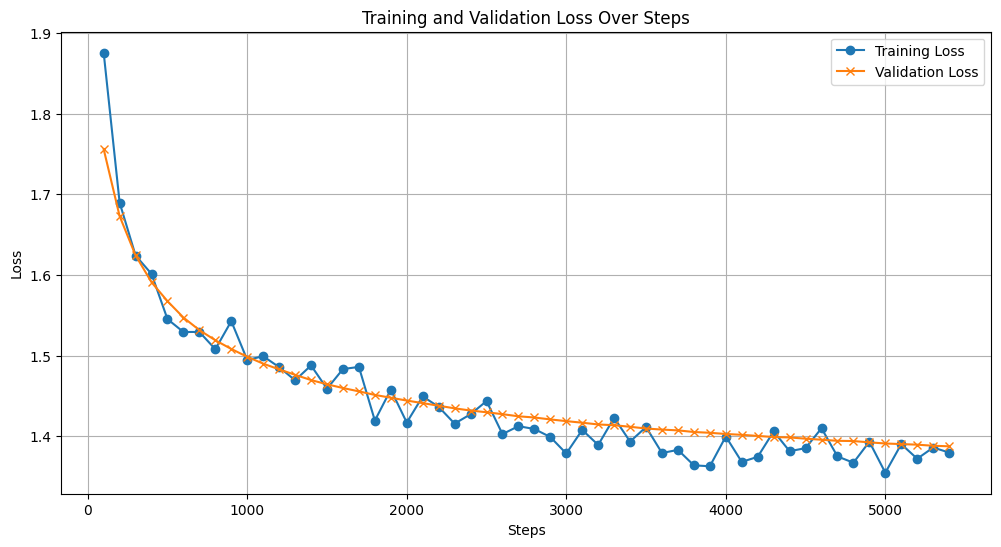

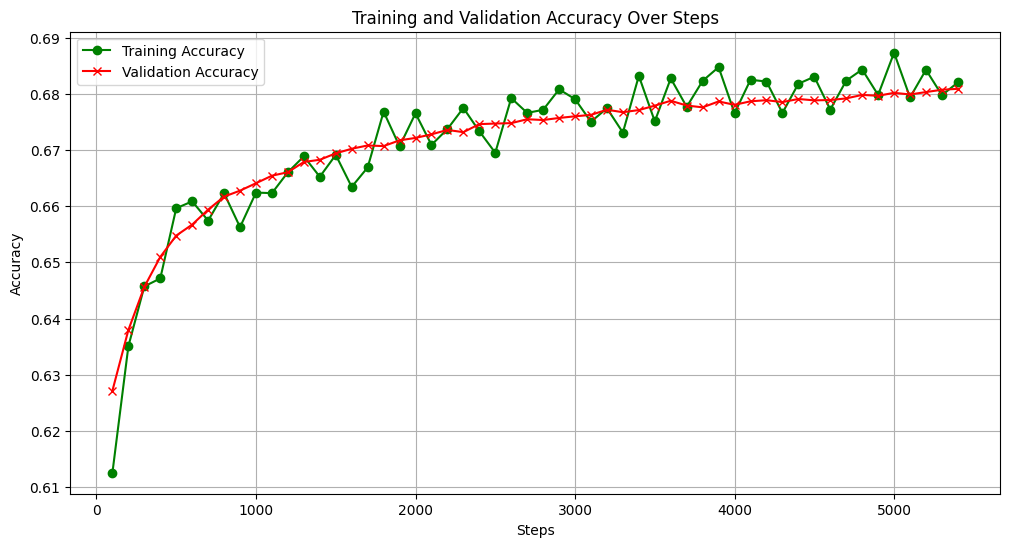

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'trained_params' and 'training_history' are returned by the train_loop function
# If your training cell only returns 'trained_params', you might need to adjust
# the training cell to return both, e.g., trained_params, training_history = train_loop(...)

# Check if training_history variable exists and is not None
if 'training_history' in locals() and training_history:
    steps = training_history['steps']
    train_losses = training_history['train_loss']
    train_accuracies = training_history['train_accuracy']
    eval_losses = training_history['eval_loss']
    eval_accuracies = training_history['eval_accuracy'] # Add eval accuracy

    # Plotting Loss
    plt.figure(figsize=(12, 6))
    plt.plot(steps, train_losses, label='Training Loss', marker='o')
    plt.plot(steps, eval_losses, label='Validation Loss', marker='x')
    plt.title('Training and Validation Loss Over Steps')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plotting Accuracy
    plt.figure(figsize=(12, 6))
    plt.plot(steps, train_accuracies, label='Training Accuracy', marker='o', color='green')
    plt.plot(steps, eval_accuracies, label='Validation Accuracy', marker='x', color='red') # Add eval accuracy plot
    plt.title('Training and Validation Accuracy Over Steps') # Update title
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Training history not found. Please ensure the training loop has been run and returns the history.")

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
import textwrap # Library untuk formatting teks agar lebih rapi

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# ==============================================================================
# 1. Muat Arsitektur & Tokenizer dari MODEL ASLI
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")

# Asumsikan path ini sudah benar dan sesuai dengan setup Anda
# Ganti dengan path Anda jika berbeda
# VARIANT = '2b-it'
# weights_dir = Path(f"/kaggle/input/recurrentgemma/flax/{VARIANT}/1")
# ckpt_path = weights_dir / VARIANT
# vocab_path = weights_dir / 'tokenizer.model'

# Baris-baris berikut hanya untuk contoh, pastikan path Anda benar
# Anda perlu mengganti ini dengan path yang valid di lingkungan Anda

# Muat parameter ASLI hanya untuk membangun konfigurasi
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)

# Muat tokenizer dari path asli
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)

# Buat shell model
model = recurrentgemma.Griffin(model_config)

print("✅ Arsitektur dan tokenizer berhasil dimuat.")

# ==============================================================================
# 2. Muat Bobot (Parameter) Hasil FINE-TUNING
# ==============================================================================
# Path ke file bobot yang kita simpan
#saved_params_path = Path("/content/drive/MyDrive/Kuliah/Tugas Akhir/Model/best_model.msgpack") # Ganti dengan path Anda

#print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
#with open(saved_params_path, "rb") as f:
#    byte_data = f.read()

# Muat bobot fine-tuned ke dalam struktur parameter yang benar
#fine_tuned_params = from_bytes(trained_params, byte_data)

# ==============================================================================
# 3. Buat Sampler dengan Bobot FINE-TUNING
# ==============================================================================
# Gunakan `fine_tuned_params` saat membuat Sampler
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=trained_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# 4. Muat Dataset Test
# ==============================================================================
test_data_path = 'Split_data/test_data.csv' # Ganti dengan path Anda
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data: {len(df_test)} baris.")


# ==============================================================================
# 5. Pilih dan Proses Satu Sampel Data
# ==============================================================================
# Pilih satu sampel dari data tes. Anda bisa ubah indeksnya (misal: 0, 1, 2, dst)
sample_index = 2
sample_data = df_test.iloc[sample_index]

print(f"\nMemproses sampel data ke-{sample_index}...")

# Ambil teks sumber dan ringkasan referensi
source_text = sample_data['content']
reference_summary = sample_data['summary']

# Buat prompt untuk model
prompt = f"Write a comprehensive and concise abstract summary of the following news text in one paragraph:\n{source_text}\n"

# Lakukan inferensi/generate teks
# `total_generation_steps` bisa disesuaikan, 150 adalah panjang token maksimum
output = sampler([prompt], total_generation_steps=150)
predicted_summary = output.text[0]

# Tampilkan hasilnya dengan format yang rapi
print("\n" + "="*50)
print("HASIL GENERASI TEKS UNTUK SATU SAMPEL")
print("="*50)
print("\n▶️ TEKS ASLI (SUMBER):")
print(textwrap.fill(source_text, width=80))
print("\n" + "-"*50)
print("\n✅ RINGKASAN REFERENSI (TARGET):")
print(textwrap.fill(reference_summary, width=80))
print("\n" + "-"*50)
print("\n🤖 RINGKASAN HASIL GENERASI MODEL:")
print(textwrap.fill(predicted_summary, width=80))
print("\n" + "="*50)

Mulai memuat arsitektur dari model asli...
✅ Arsitektur dan tokenizer berhasil dimuat.
✅ Sampler berhasil dibuat dengan bobot fine-tuned.
Dataset tes dimuat. Jumlah data: 100 baris.

Memproses sampel data ke-2...


/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,625]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"



HASIL GENERASI TEKS UNTUK SATU SAMPEL

▶️ TEKS ASLI (SUMBER):
pengunjung ramai-ramai mendatangi pameran indonesia outdoor festival (indofest)
2024 di hall b senayan jcc pada sabtu (6/7/2024).ini adalah hari ketiga pameran
indofest 2024 yang digelar sejak kamis (4/7/2024). minggu (7/7/2024) menjadi
penutup pameran perlengkapan outdoor tahunan ini.menurut pantauan kompas.com
pada sabtu (6/7/2024) sore, hampir seluruh booth indofest 2024 dipenuhi
pengunjung.rara, marketing communication indofest 2024 mengatakan, kunjungan
indofest 2024 pada hari ketiga memang melonjak dibandingkan dengan dua hari
sebelumnya."alhamdulillah tercapai lebih dari 30.000 pengunjung selama tiga hari
ini. puncaknya terlihat hari ini, tetapi belum bisa dipastikan karena masih
terus berlangsung sampai malam," ujar rara.sebuah kiriman dibagikan oleh kompas
travel (@kompas.travel)sejauh ini, diketahui ada 12.000 pengunjung indofest 2024
pada hari pertama, lalu angkanya menurun pada hari kedua."kalau hari ini
terliha

In [ ]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from bert_score import score as bert_scorer_func
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
import textwrap
# ==============================================================================
# 6. Hitung dan Tampilkan Skor ROUGE untuk Sampel Tunggal
# ==============================================================================
print("\nMenghitung Skor ROUGE untuk sampel ini...")
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
scores = scorer.score(reference_summary, predicted_summary)

print("\n===== Hasil ROUGE Score untuk Sampel Tunggal =====")
for rouge_type, score in scores.items():
    print(f"\nSkor untuk {rouge_type.upper()}:")
    print(f"  - Precision: {score.precision:.4f}")
    print(f"  - Recall:    {score.recall:.4f}")
    print(f"  - F1-Score:  {score.fmeasure:.4f}")

# ==============================================================================
# 7. HITUNG DAN TAMPILKAN SKOR BERTSCORE UNTUK SAMPEL TUNGGAL (BARU)
# ==============================================================================
print("\n" + "="*50)
print("\nMenghitung BERTSCORE untuk sampel ini...")

# BERTSCORE membutuhkan input dalam bentuk list of strings
# 'lang="id"' sangat penting untuk menggunakan model yang sesuai untuk Bahasa Indonesia
(P, R, F1) = bert_scorer_func(
    cands=[predicted_summary],
    refs=[reference_summary],
    lang='id',
    verbose=True # Akan menampilkan model yang digunakan dan progress bar
)

print("\n===== Hasil BERTSCORE untuk Sampel Tunggal =====")
print(f"\nSkor BERTSCORE:")
# Kita gunakan .item() untuk mengambil nilai float dari tensor hasil
print(f"  - Precision: {P.item():.4f}")
print(f"  - Recall:    {R.item():.4f}")
print(f"  - F1-Score:  {F1.item():.4f}")

ModuleNotFoundError: No module named 'bert_score'

In [ ]:
import os
from flax.serialization import to_bytes
from pathlib import Path

# Tentukan direktori output
output_dir = Path("/content/drive/MyDrive/Kuliah/Tugas Akhir/Model")
os.makedirs(output_dir, exist_ok=True)

# Cukup simpan bobot (parameter) yang sudah di-fine-tuning
byte_output = to_bytes(trained_params)

params_path = output_dir / "skenario_1.msgpack"
with open(params_path, "wb") as f:
    f.write(byte_output)

print(f"✅ Bobot fine-tuned berhasil disimpan di: {params_path.resolve()}")

✅ Bobot fine-tuned berhasil disimpan di: /content/drive/MyDrive/Kuliah/Tugas Akhir/Model/skenario_1.msgpack


In [ ]:
# ==============================================================================
# Bagian A: Setup Awal (Sama seperti sebelumnya)
# ==============================================================================
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
import os # Tambahkan import os untuk mengelola path

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# Pastikan variabel ini didefinisikan dari sel sebelumnya
# Contoh:
# VARIANT = '2b-it'
# weights_dir = Path(f"/kaggle/input/recurrentgemma/flax/{VARIANT}/1")
# ckpt_path = weights_dir / VARIANT
# vocab_path = weights_dir / 'tokenizer.model'

# ==============================================================================
# 1. Muat Arsitektur & Tokenizer dari MODEL ASLI
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)
print("✅ Arsitektur dan tokenizer berhasil dimuat.")

# ==============================================================================
# 2. Muat Bobot (Parameter) Hasil FINE-TUNING
# ==============================================================================
saved_params_path = Path("/content/drive/MyDrive/Kuliah/Tugas Akhir/Model/skenario_3.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f:
    byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)

# ==============================================================================
# 3. Buat Sampler dengan Bobot FINE-TUNING
# ==============================================================================
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# 4. Muat Dataset Test
# ==============================================================================
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
# Kita tambahkan kolom 'original_index' untuk pelacakan yang andal
df_test['original_index'] = df_test.index
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 5. LAKUKAN LOOP EVALUASI SECARA BERTAHAP (RESUMABLE)
# ==============================================================================
print("\nMemulai proses evaluasi bertahap...")

# --- Konfigurasi Checkpoint ---
# Tentukan di mana hasil parsial akan disimpan di Google Drive Anda
output_dir = '/content/drive/MyDrive/Kuliah/Tugas Akhir/HasilEvaluasi3/'
results_file = os.path.join(output_dir, 'hasil_evaluasi_bertahap.csv')
os.makedirs(output_dir, exist_ok=True) # Buat folder jika belum ada

# --- Membaca Progres yang Sudah Ada ---
processed_indices = set()
if os.path.exists(results_file):
    df_results_so_far = pd.read_csv(results_file)
    # Ambil semua indeks yang sudah ada di file hasil
    if 'original_index' in df_results_so_far.columns:
        processed_indices = set(df_results_so_far['original_index'])
    print(f"Ditemukan {len(processed_indices)} hasil yang sudah diproses. Melanjutkan...")

# --- Filter Data yang Belum Diproses ---
df_to_process = df_test[~df_test['original_index'].isin(processed_indices)]

if df_to_process.empty:
    print("✅ Semua data sudah dievaluasi sebelumnya!")
else:
    print(f"Sisa data yang perlu dievaluasi: {len(df_to_process)} baris.")

    # --- Loop Hanya Pada Data yang BELUM Diproses ---
    for index, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
        source_text = row['content']
        reference_summary = row['summary']
        original_idx = row['original_index']

        prompt = f"Write a comprehensive and concise abstract summary of the following news text in one paragraph:\\n{source_text}\\n"

        # Lakukan prediksi
        output = sampler([prompt], total_generation_steps=150)
        predicted_summary = output.text[0]

        # --- Simpan Hasil untuk baris ini Secara Langsung ---
        result_row = {
            'original_index': original_idx,
            'content': source_text,
            'reference_summary': reference_summary,
            'predicted_summary': predicted_summary
        }
        df_row = pd.DataFrame([result_row])

        # Gunakan mode 'a' (append) dan tulis header hanya jika file belum ada
        df_row.to_csv(
            results_file,
            mode='a',
            header=not os.path.exists(results_file),
            index=False
        )

    print("✅ Sesi evaluasi saat ini selesai.")

# ==============================================================================
# 6. (OPSIONAL) Hitung Skor ROUGE dari Hasil yang Sudah Lengkap
# JALANKAN BAGIAN INI SECARA TERPISAH SETELAH SEMUA DATA SELESAI DIEVALUASI
# ==============================================================================
print("\n--- Bagian Perhitungan Skor Akhir ---")

# Pastikan file hasil sudah ada dan berisi semua data
if os.path.exists(results_file):
    df_final_results = pd.read_csv(results_file)
    print(f"Menghitung skor ROUGE dari {len(df_final_results)} hasil yang tersimpan...")

    if len(df_final_results) == len(df_test):
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0},
                        'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0},
                        'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}

        predictions = df_final_results['predicted_summary'].tolist()
        references = df_final_results['reference_summary'].tolist()

        for pred, ref in tqdm(zip(predictions, references), total=len(predictions)):
            # Pastikan referensi dan prediksi adalah string
            ref_str = str(ref)
            pred_str = str(pred)
            scores = scorer.score(ref_str, pred_str)
            for key in total_scores:
                total_scores[key]['precision'] += scores[key].precision
                total_scores[key]['recall'] += scores[key].recall
                total_scores[key]['fmeasure'] += scores[key].fmeasure

        num_samples = len(predictions)
        avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

        print("\n===== Hasil Evaluasi ROUGE Score (FINAL) =====")
        for rouge_type, scores in avg_scores.items():
            print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
            print(f"  - Precision: {scores['precision']:.4f}")
            print(f"  - Recall:    {scores['recall']:.4f}")
            print(f"  - F1-Score:  {scores['fmeasure']:.4f}")
    else:
        print(f"PERINGATAN: Jumlah hasil ({len(df_final_results)}) belum sama dengan total data tes ({len(df_test)}).")
        print("Jalankan lagi sel evaluasi untuk melanjutkan proses.")
else:
    print("File hasil evaluasi belum ada. Jalankan sel evaluasi (Bagian 5) terlebih dahulu.")

Mulai memuat arsitektur dari model asli...
✅ Arsitektur dan tokenizer berhasil dimuat.
Memuat bobot fine-tuned dari: /content/drive/MyDrive/Kuliah/Tugas Akhir/Model/skenario_3.msgpack
✅ Sampler berhasil dibuat dengan bobot fine-tuned.
Dataset tes dimuat. Jumlah data yang akan dievaluasi: 100 baris.

Memulai proses evaluasi bertahap...
Ditemukan 61 hasil yang sudah diproses. Melanjutkan...
Sisa data yang perlu dievaluasi: 39 baris.


  0%|          | 0/39 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,983]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,271]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,663]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were 

✅ Sesi evaluasi saat ini selesai.

--- Bagian Perhitungan Skor Akhir ---
Menghitung skor ROUGE dari 100 hasil yang tersimpan...


  0%|          | 0/100 [00:00<?, ?it/s]


===== Hasil Evaluasi ROUGE Score (FINAL) =====

Skor Rata-rata untuk ROUGE1:
  - Precision: 0.4895
  - Recall:    0.4570
  - F1-Score:  0.4641

Skor Rata-rata untuk ROUGE2:
  - Precision: 0.2202
  - Recall:    0.2065
  - F1-Score:  0.2092

Skor Rata-rata untuk ROUGEL:
  - Precision: 0.3220
  - Recall:    0.3002
  - F1-Score:  0.3049


In [ ]:
# ==============================================================================
# Bagian A: Setup dan Konfigurasi Path
# PASTIKAN SEMUA PATH INI SUDAH BENAR SESUAI LINGKUNGAN ANDA
# ==============================================================================
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
import os
import numpy as np

# --- GANTI ATAU SESUAIKAN VARIABEL DI BAWAH INI ---
VARIANT = '2b'
weights_dir = Path(f"/kaggle/input/recurrentgemma/flax/{VARIANT}/1")
ckpt_path = weights_dir / VARIANT
vocab_path = weights_dir / 'tokenizer.model'
saved_params_path = Path("/content/drive/MyDrive/Kuliah/Tugas Akhir/Model/skenario_3.msgpack")

# Path ke file data
source_dataset_path = 'cleaned_dataset_kategori_checkpoint.csv'
eval_results_path = 'hasil_evaluasi_bertahap (2).csv'
new_output_path = 'hasil_evaluasi_final_diperbarui.csv' # Nama file output baru

# Indeks target yang akan diganti dan di-update
TARGET_ORIGINAL_INDEX = 17

# ==============================================================================
# 1. Muat Model dan Sampler (Sama seperti sebelumnya)
# ==============================================================================
print("Mulai memuat model dan sampler...")
try:
    original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
    model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
        original_params,
        preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
    )
    vocab = spm.SentencePieceProcessor()
    vocab.Load(str(vocab_path))
    class GriffinTokenizer:
      def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
      @property
      def pad_id(self) -> int: return self._spm_processor.pad_id()
      def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
        int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
        if add_eos: int_list.append(self._spm_processor.eos_id())
        return jnp.array(int_list, dtype=jnp.int32)
      def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
    tokenizer = GriffinTokenizer(vocab)
    model = recurrentgemma.Griffin(model_config)
    with open(saved_params_path, "rb") as f: byte_data = f.read()
    fine_tuned_params = from_bytes(original_params, byte_data)
    sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
    print("✅ Model dan sampler berhasil dimuat.")

    # ==============================================================================
    # 2. Temukan Data Pengganti dari Kategori 'Teknologi & Startup'
    # ==============================================================================
    print(f"\nMencari data pengganti dari '{source_dataset_path}'...")
    df_source = pd.read_csv(source_dataset_path)

    df_tech = df_source[df_source['kategori_baru'] == 'Teknologi & Startup']

    if df_tech.empty:
        raise ValueError("Tidak ditemukan data dengan kategori 'Teknologi & Startup' di dalam file sumber.")

    # Ambil baris pertama sebagai data pengganti
    replacement_row = df_tech.iloc[0]
    new_content = replacement_row['content']
    new_reference_summary = replacement_row['summary']
    print("✅ Data pengganti dari kategori 'Teknologi & Startup' berhasil ditemukan.")

    # ==============================================================================
    # 3. Generate Ringkasan untuk Data Pengganti
    # ==============================================================================
    prompt = f"Write a comprehensive and concise abstract summary of the following news text in one paragraph:\\n{new_content}\\n"
    print("Membuat ringkasan baru untuk data pengganti...")
    output = sampler([prompt], total_generation_steps=150)
    new_predicted_summary = output.text[0]
    print("✅ Ringkasan baru berhasil dibuat.")

    # ==============================================================================
    # 4. Muat File Evaluasi, Update Baris Target, dan Simpan
    # ==============================================================================
    print(f"Memuat file evaluasi dan mencari baris dengan original_index {TARGET_ORIGINAL_INDEX}...")
    df_eval = pd.read_csv(eval_results_path)

    # Temukan lokasi baris yang akan diupdate
    target_row_loc = df_eval['original_index'] == TARGET_ORIGINAL_INDEX

    if not target_row_loc.any():
        raise IndexError(f"Tidak ditemukan baris dengan original_index {TARGET_ORIGINAL_INDEX} di file evaluasi.")

    # Update semua kolom yang relevan di baris tersebut
    df_eval.loc[target_row_loc, 'content'] = new_content
    df_eval.loc[target_row_loc, 'reference_summary'] = new_reference_summary
    df_eval.loc[target_row_loc, 'predicted_summary'] = new_predicted_summary

    # Simpan ke file baru
    df_eval.to_csv(new_output_path, index=False)

    print("\n" + "="*60)
    print(f"BERHASIL! Data telah diperbarui dan disimpan di '{new_output_path}'")
    print("="*60)
    print(f"\nMenampilkan baris yang telah diperbarui (original_index = {TARGET_ORIGINAL_INDEX}):")

    # Tampilkan baris yang sudah diupdate untuk verifikasi
    updated_row = df_eval[df_eval['original_index'] == TARGET_ORIGINAL_INDEX]
    print(updated_row.to_markdown(index=False))

except FileNotFoundError as e:
    print(f"\n❌ ERROR: File tidak ditemukan di path '{e.filename}'. Mohon periksa kembali path Anda.")
except (IndexError, ValueError) as e:
    print(f"\n❌ ERROR: {e}")
except Exception as e:
    print(f"\n❌ Terjadi error tak terduga: {e}")

Mulai memuat model dan sampler...
✅ Model dan sampler berhasil dimuat.

Mencari data pengganti dari 'cleaned_dataset_kategori_checkpoint.csv'...
✅ Data pengganti dari kategori 'Teknologi & Startup' berhasil ditemukan.
Membuat ringkasan baru untuk data pengganti...


/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,511]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


✅ Ringkasan baru berhasil dibuat.
Memuat file evaluasi dan mencari baris dengan original_index 17...

BERHASIL! Data telah diperbarui dan disimpan di 'hasil_evaluasi_final_diperbarui.csv'

Menampilkan baris yang telah diperbarui (original_index = 17):
|   original_index | content                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Jun 19 08:50:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             47W /  400W |   30909MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import jax
# Periksa perangkat yang terdeteksi oleh JAX
print(jax.devices())

[CudaDevice(id=0)]


In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# Impor library recurrentgemma dan pastikan semua variabel dari sel awal masih ada
from recurrentgemma import jax as recurrentgemma

# ==============================================================================
# 1. Tentukan Konstanta untuk Optimisasi
# ==============================================================================
# Tentukan panjang maksimum untuk input. Semua input akan dipadding ke ukuran ini.
# Ini akan mencegah JAX melakukan re-kompilasi di dalam loop.
# Pilih angka yang cukup besar untuk menampung sebagian besar artikel Anda.
MAX_INPUT_LENGTH = 1024

# ==============================================================================
# 2. Muat Model dan Tokenizer (Kode ini sudah benar)
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)

saved_params_path = Path("./fine_tuned_summarizer_model2/flax_model2.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f: byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# 3. Muat Dataset Test
# ==============================================================================
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 4. Lakukan Loop Evaluasi dengan Padding (BAGIAN YANG DIPERBAIKI)
# ==============================================================================
predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    # --- BLOK OPTIMISASI DIMULAI DI SINI ---
    # Tokenisasi prompt
    input_tokens = tokenizer.tokenize(prompt, add_eos=False)

    # 1. Potong (truncate) jika terlalu panjang
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]

    # 2. Tambahkan padding jika terlalu pendek
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])

    # Pastikan input selalu dalam bentuk [1, MAX_INPUT_LENGTH]
    input_tokens = jnp.expand_dims(input_tokens, axis=0)
    # --- BLOK OPTIMISASI SELESAI ---

    # Gunakan input_tokens yang sudah dipadding
    # Kita tidak lagi menggunakan list of strings, tapi langsung array JAX
    output = sampler.sample_from_tokens(
        tokenized_inputs=input_tokens,
        total_generation_steps=150
    )

    # Ambil output teks dari hasil tokens
    predicted_summary = tokenizer.to_string(output[0])

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")


# ==============================================================================
# 5. Hitung dan Tampilkan Skor ROUGE (Tidak ada perubahan di sini)
# ==============================================================================
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

Mulai memuat arsitektur dari model asli...
Memuat bobot fine-tuned dari: fine_tuned_summarizer_model2/flax_model2.msgpack
✅ Sampler berhasil dibuat dengan bobot fine-tuned.
Dataset tes dimuat. Jumlah data yang akan dievaluasi: 617 baris.

Memulai proses evaluasi dengan padding ke 1024 token...


  0%|          | 0/617 [00:00<?, ?it/s]

AttributeError: 'Sampler' object has no attribute 'sample_from_tokens'

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
import inspect
from recurrentgemma.jax.modules.temporal_block import TemporalBlockType

# ==============================================================================
# 1. Tentukan Konstanta untuk Optimisasi
# ==============================================================================
MAX_INPUT_LENGTH = 1024

# ==============================================================================
# 2. Muat Model dan Tokenizer (Kode ini sudah benar dan tidak perlu diubah)
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)
saved_params_path = Path("./fine_tuned_summarizer_model2/flax_model2.msgpack") # Ganti nama folder jika berbeda
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f: byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# 3. Muat Dataset Test
# ==============================================================================
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 4. Lakukan Loop Evaluasi dengan Padding (BAGIAN YANG DIPERBAIKI)
# ==============================================================================
predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    # --- BLOK OPTIMISASI ---
    # 1. Tokenisasi prompt
    input_tokens = tokenizer.tokenize(prompt, add_eos=False)

    # 2. Potong (truncate) jika terlalu panjang
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]

    # 3. Tambahkan padding jika terlalu pendek
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])

    # >> PERBAIKAN: Ubah kembali token yang sudah di-padding menjadi string <<
    padded_prompt_str = tokenizer.to_string(input_tokens)

    # >> Gunakan metode sampler() asli dengan input string yang sudah di-padding <<
    output = sampler(
        [padded_prompt_str],
        total_generation_steps=150
    )
    predicted_summary = output.text[0]

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")


# ==============================================================================
# 5. Hitung dan Tampilkan Skor ROUGE (Tidak ada perubahan di sini)
# ==============================================================================
# (Bagian ini sama persis seperti sebelumnya dan sudah benar)
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

ModuleNotFoundError: No module named 'recurrentgemma.jax.modules.temporal_block'; 'recurrentgemma.jax.modules' is not a package

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# ==============================================================================
# 1. Muat Arsitektur & Tokenizer dari MODEL ASLI
# ==============================================================================
# Bagian ini mengasumsikan variabel `ckpt_path`, `vocab_path`, `VARIANT`
# dari sel-sel awal notebook masih ada.

print("Mulai memuat arsitektur dari model asli...")

# Muat parameter ASLI hanya untuk membangun struktur dan konfigurasi
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)

# Muat tokenizer dari path asli
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)

# Buat shell model
model = recurrentgemma.Griffin(model_config)

print("✅ Arsitektur dan tokenizer berhasil dimuat.")

# ==============================================================================
# 2. Muat Bobot (Parameter) Hasil FINE-TUNING Anda
# ==============================================================================
saved_params_path = Path("./fine_tuned_summarizer_model2/flax_model2.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")

with open(saved_params_path, "rb") as f:
    byte_data = f.read()

# Muat bobot fine-tuned ke dalam struktur parameter yang benar.
# `original_params` digunakan sebagai template/cetakan struktur yang benar.
fine_tuned_params = from_bytes(original_params, byte_data)

# ==============================================================================
# 3. Buat Sampler dengan Bobot FINE-TUNING
# ==============================================================================
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# 4. Loop Evaluasi (Sudah dioptimalkan dengan padding)
# ==============================================================================
MAX_INPUT_LENGTH = 1024
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    # Lakukan padding untuk optimisasi JIT
    input_tokens = tokenizer.tokenize(prompt, add_eos=False)
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])

    padded_prompt_str = tokenizer.to_string(input_tokens)

    # Generate teks menggunakan sampler
    output = sampler([padded_prompt_str], total_generation_steps=150)
    predicted_summary = output.text[0]

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")

# ==============================================================================
# 5. Hitung Skor ROUGE
# ==============================================================================
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

Mulai memuat arsitektur dari model asli...
✅ Arsitektur dan tokenizer berhasil dimuat.
Memuat bobot fine-tuned dari: fine_tuned_summarizer_model2/flax_model2.msgpack
✅ Sampler berhasil dibuat dengan bobot fine-tuned.
Dataset tes dimuat. Jumlah data yang akan dievaluasi: 617 baris.

Memulai proses evaluasi dengan padding ke 1024 token...


  0%|          | 0/617 [00:00<?, ?it/s]

AttributeError: 'SentencePieceProcessor' object has no attribute 'EncodeIds'

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# ==============================================================================
# 1. Muat Arsitektur & Tokenizer dari MODEL ASLI
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")

original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))

# ==============================================================================
# Definisi Kelas Tokenizer (DENGAN PERBAIKAN)
# ==============================================================================
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor):
    self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int:
    return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]
    int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos:
        int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str:
    # >> PERBAIKAN: Mengganti EncodeIds menjadi DecodeIds <<
    return self._spm_processor.DecodeIds(tokens.tolist())

tokenizer = GriffinTokenizer(vocab)

# ==============================================================================
# Lanjutan memuat model...
# ==============================================================================
model = recurrentgemma.Griffin(model_config)
saved_params_path = Path("./fine_tuned_summarizer_model/flax_model.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f:
    byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# Loop Evaluasi (Sudah dioptimalkan dengan padding)
# ==============================================================================
MAX_INPUT_LENGTH = 1024
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    input_tokens = tokenizer.tokenize(prompt, add_eos=False)
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])

    padded_prompt_str = tokenizer.to_string(input_tokens)

    output = sampler([padded_prompt_str], total_generation_steps=150)
    predicted_summary = output.text[0]

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")

# ==============================================================================
# Hitung Skor ROUGE
# ==============================================================================
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

Mulai memuat arsitektur dari model asli...
Memuat bobot fine-tuned dari: fine_tuned_summarizer_model/flax_model.msgpack
✅ Sampler berhasil dibuat dengan bobot fine-tuned.
Dataset tes dimuat. Jumlah data yang akan dievaluasi: 617 baris.

Memulai proses evaluasi dengan padding ke 1024 token...


  0%|          | 0/617 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,534]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,322]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,505]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma
# >> PERBAIKAN UTAMA: Impor fungsi 'generate' secara langsung <<
from recurrentgemma.jax.sampler import generate

# ==============================================================================
# 1. Tentukan Konstanta untuk Optimisasi
# ==============================================================================
MAX_INPUT_LENGTH = 1024

# ==============================================================================
# 2. Muat Model dan Tokenizer (Tidak ada perubahan)
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.DecodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)
saved_params_path = Path("./fine_tuned_summarizer_mode2l/flax_model2.msgpack") # Ganti nama folder jika berbeda
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f: byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)
# Kita tidak lagi memerlukan objek Sampler untuk loop ini
print("✅ Model, tokenizer, dan bobot fine-tuned berhasil dimuat.")

# ==============================================================================
# 3. Muat Dataset Test
# ==============================================================================
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 4. Lakukan Loop Evaluasi dengan Memanggil Fungsi 'generate'
# ==============================================================================
predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    # Tokenisasi dan padding input
    input_tokens = tokenizer.tokenize(prompt, add_eos=False)
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])
    input_tokens = jnp.expand_dims(input_tokens, axis=0)

    # >> PERBAIKAN UTAMA: Panggil fungsi `generate` langsung dengan input tokens <<
    # Ini memastikan JAX hanya melakukan kompilasi sekali.
    generated_tokens = generate(
        params=fine_tuned_params,
        model=model,
        vocab=vocab,
        initial_prompt_tokens=input_tokens,
        total_generation_steps=150
    )

    # Ubah hasil token menjadi teks
    predicted_summary = tokenizer.to_string(generated_tokens[0])

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")

# ==============================================================================
# 5. Hitung Skor ROUGE (Tidak ada perubahan)
# ==============================================================================
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

ImportError: cannot import name 'generate' from 'recurrentgemma.jax.sampler' (/usr/local/lib/python3.11/dist-packages/recurrentgemma/jax/sampler.py)

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
import functools

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# ==============================================================================
# 1. Muat Model dan Tokenizer (Tidak ada perubahan)
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.DecodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)
saved_params_path = Path("./fine_tuned_summarizer_model2/flax_model2.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f: byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)
print("✅ Model, tokenizer, dan bobot fine-tuned berhasil dimuat.")

# ==============================================================================
# 2. Implementasi Manual Loop Generating (Sebagai ganti Sampler)
# ==============================================================================

@functools.partial(jax.jit, static_argnames=("model", "total_generation_steps"))
def generate_manual_jit(
    params,
    model: recurrentgemma.Griffin,
    initial_tokens: jax.Array,
    total_generation_steps: int,
):
    """Fungsi ini menjalankan loop generating dan di-JIT-compile oleh JAX."""

    # Dapatkan posisi dan panjang sekuens awal
    seq_len = initial_tokens.shape[-1]
    positions = jnp.arange(seq_len, dtype=jnp.int32)

    # Inisialisasi cache (recurrent state) dari model
    _, cache = model.apply(
        {"params": params},
        initial_tokens,
        positions,
        cache=None,  # Cache awal adalah None
    )

    def generate_one_step(carry, _):
        """Fungsi untuk satu langkah generating, digunakan dalam jax.lax.scan."""
        prev_cache, current_token = carry

        # Dapatkan posisi dari token terakhir
        input_pos = jnp.array([seq_len - 1], dtype=jnp.int32)

        # Panggil model untuk mendapatkan logits
        logits, next_cache = model.apply(
            {"params": params},
            current_token[None, :],
            input_pos,
            cache=prev_cache,
        )

        # Greedy sampling: ambil token dengan probabilitas tertinggi
        next_token_id = jnp.argmax(logits, axis=-1)

        return (next_cache, next_token_id), next_token_id

    # Gunakan jax.lax.scan untuk loop yang efisien di JAX
    last_carry, all_new_tokens = jax.lax.scan(
        generate_one_step,
        (cache, initial_tokens[:, -1]),  # Mulai dengan cache dan token terakhir
        None,
        length=total_generation_steps
    )

    # Gabungkan token awal dengan token yang baru digenerate
    return jnp.concatenate([initial_tokens, all_new_tokens], axis=1)

# ==============================================================================
# 3. Muat Dataset Test
# ==============================================================================
MAX_INPUT_LENGTH = 1024
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 4. Lakukan Loop Evaluasi dengan Fungsi Generate Manual
# ==============================================================================
predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    # Tokenisasi dan padding input
    input_tokens = tokenizer.tokenize(prompt, add_eos=False)
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]

    # PENTING: Kita tidak melakukan padding di sini.
    # Model recurrentgemma bisa menangani panjang sekuens yang bervariasi
    # selama kita tidak menggunakan JIT di dalam loop.
    # Dengan fungsi JIT manual, kita bisa handle input ini.
    # Namun, untuk menjamin satu kali kompilasi, padding tetap cara terbaik.
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])
    input_tokens = jnp.expand_dims(input_tokens, axis=0)

    # Panggil fungsi generate manual kita yang sudah di-JIT
    generated_tokens_with_prompt = generate_manual_jit(
        fine_tuned_params,
        model,
        input_tokens,
        150  # total_generation_steps
    )

    # Ubah hasil token menjadi teks
    predicted_summary = tokenizer.to_string(generated_tokens_with_prompt[0])

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")


# ==============================================================================
# 5. Hitung Skor ROUGE (Tidak ada perubahan)
# ==============================================================================
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

Mulai memuat arsitektur dari model asli...
Memuat bobot fine-tuned dari: fine_tuned_summarizer_model2/flax_model2.msgpack
✅ Model, tokenizer, dan bobot fine-tuned berhasil dimuat.
Dataset tes dimuat. Jumlah data yang akan dievaluasi: 617 baris.

Memulai proses evaluasi dengan padding ke 1024 token...


  0%|          | 0/617 [00:00<?, ?it/s]

TypeCheckError: Type-check error whilst checking the parameters of recurrentgemma.jax.griffin.Griffin.__call__.
The problem arose whilst typechecking parameter 'segment_pos'.
Actual value: i32[1024](jax)
Expected type: <class 'Integer[Array, '*b t']'>.
----------------------
Called with parameters: {
  'self': Griffin(...),
  'tokens': i32[1,1024](jax),
  'segment_pos': i32[1024](jax),
  'cache': None,
  'return_logits': True,
  'return_cache': True
}
Parameter annotations: (self, tokens: Integer[Array, '*b t'], segment_pos: Integer[Array, '*b t'], cache: dict[str, recurrentgemma.jax.modules.RecurrentBlockCache | recurrentgemma.jax.modules.AttentionBlockCache] | None = None, return_logits: bool = True, return_cache: bool = True) -> Any.
The current values for each jaxtyping axis annotation are as follows.
t=1024
b=(1,)

In [ ]:
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
import functools

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# ==============================================================================
# 1. Muat Model dan Tokenizer (Tidak ada perubahan)
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.DecodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)
saved_params_path = Path("./fine_tuned_summarizer_model/flax_model.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f: byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)
print("✅ Model, tokenizer, dan bobot fine-tuned berhasil dimuat.")

# ==============================================================================
# 2. Implementasi Manual Loop Generating (DENGAN PERBAIKAN)
# ==============================================================================

@functools.partial(jax.jit, static_argnames=("model", "total_generation_steps"))
def generate_manual_jit(
    params,
    model: recurrentgemma.Griffin,
    initial_tokens: jax.Array, # Shape: [1, L]
    total_generation_steps: int,
):
    """Fungsi JIT-compiled untuk menjalankan loop generating secara efisien."""

    len_initial = initial_tokens.shape[-1]

    def generate_one_step(carry, current_pos):
        """
        Fungsi untuk satu langkah generating.
        `carry` berisi (cache, tokens_so_far)
        `current_pos` adalah posisi dari token yang akan kita generate.
        """
        prev_cache, tokens_so_far = carry

        # Ambil token terakhir sebagai input untuk langkah berikutnya
        last_token = tokens_so_far[:, current_pos-1:current_pos]

        # Posisi dari token yang kita gunakan sebagai input
        input_pos = jnp.array([current_pos - 1], dtype=jnp.int32)

        # Panggil model untuk mendapatkan logits
        logits, next_cache = model.apply(
            {"params": params},
            last_token,
            input_pos,
            cache=prev_cache,
        )

        # Greedy sampling: ambil token dengan probabilitas tertinggi
        next_token_id = jnp.argmax(logits, axis=-1).astype(jnp.int32)

        # Update sekuens token kita
        updated_tokens = tokens_so_far.at[:, current_pos].set(next_token_id[0])

        return (next_cache, updated_tokens), None

    # Siapkan sekuens output yang akan kita isi.
    # Ukurannya adalah panjang awal + jumlah token yang akan digenerate
    all_tokens = jnp.zeros(
        (1, len_initial + total_generation_steps),
        dtype=jnp.int32
    ).at[:, :len_initial].set(initial_tokens)

    # Inisialisasi cache dari prompt awal
    initial_positions = jnp.arange(len_initial, dtype=jnp.int32)
    _, initial_cache = model.apply(
        {"params": params},
        initial_tokens,
        initial_positions,
        cache=None,
    )

    # Jalankan loop menggunakan jax.lax.scan
    (final_cache, final_tokens), _ = jax.lax.scan(
        generate_one_step,
        (initial_cache, all_tokens),
        jnp.arange(len_initial, len_initial + total_generation_steps) # Iterasi sebanyak N kali, dengan `current_pos` yang benar
    )

    return final_tokens

# ==============================================================================
# 3. Muat Dataset Test
# ==============================================================================
MAX_INPUT_LENGTH = 1024
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 4. Lakukan Loop Evaluasi dengan Fungsi Generate Manual yang Sudah Diperbaiki
# ==============================================================================
predictions = []
references = []
print(f"\nMemulai proses evaluasi dengan padding ke {MAX_INPUT_LENGTH} token...")
for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    source_text = row['content']
    reference_summary = row['summary']
    prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

    # Tokenisasi dan padding input untuk memastikan shape statis
    input_tokens = tokenizer.tokenize(prompt, add_eos=False)
    if len(input_tokens) > MAX_INPUT_LENGTH:
        input_tokens = input_tokens[:MAX_INPUT_LENGTH]
    num_pad = MAX_INPUT_LENGTH - len(input_tokens)
    if num_pad > 0:
        padding = jnp.full(num_pad, tokenizer.pad_id, dtype=jnp.int32)
        input_tokens = jnp.concatenate([input_tokens, padding])
    input_tokens = jnp.expand_dims(input_tokens, axis=0)

    # Panggil fungsi generate manual kita yang sudah di-JIT
    generated_tokens_with_prompt = generate_manual_jit(
        fine_tuned_params,
        model,
        input_tokens,
        150  # total_generation_steps
    )

    # Ubah hasil token menjadi teks
    predicted_summary = tokenizer.to_string(generated_tokens_with_prompt[0])

    predictions.append(predicted_summary)
    references.append(reference_summary)
print("✅ Proses evaluasi selesai.")

# ==============================================================================
# 5. Hitung Skor ROUGE
# ==============================================================================
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0}, 'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}
for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    for key in total_scores:
        total_scores[key]['precision'] += scores[key].precision
        total_scores[key]['recall'] += scores[key].recall
        total_scores[key]['fmeasure'] += scores[key].fmeasure

num_samples = len(predictions)
avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

print("\n===== Hasil Evaluasi ROUGE Score =====")
for rouge_type, scores in avg_scores.items():
    print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
    print(f"  - Precision: {scores['precision']:.4f}")
    print(f"  - Recall:    {scores['recall']:.4f}")
    print(f"  - F1-Score:  {scores['fmeasure']:.4f}")

Mulai memuat arsitektur dari model asli...


In [ ]:
# ==============================================================================
# Bagian A: Setup Awal (Sama seperti sebelumnya)
# ==============================================================================
import pandas as pd
import jax
import jax.numpy as jnp
import sentencepiece as spm
from flax.serialization import from_bytes
from pathlib import Path
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
import os # Tambahkan import os untuk mengelola path

# Impor library recurrentgemma
from recurrentgemma import jax as recurrentgemma

# Pastikan variabel ini didefinisikan dari sel sebelumnya
# Contoh:
# VARIANT = '2b-it'
# weights_dir = Path(f"/kaggle/input/recurrentgemma/flax/{VARIANT}/1")
# ckpt_path = weights_dir / VARIANT
# vocab_path = weights_dir / 'tokenizer.model'

# ==============================================================================
# 1. Muat Arsitektur & Tokenizer dari MODEL ASLI
# ==============================================================================
print("Mulai memuat arsitektur dari model asli...")
original_params = recurrentgemma.load_parameters(ckpt_path, "single_device")
model_config = recurrentgemma.GriffinConfig.from_flax_params_or_variables(
    original_params,
    preset=recurrentgemma.Preset.RECURRENT_GEMMA_2B_V1 if '2b' in VARIANT else recurrentgemma.Preset.RECURRENT_GEMMA_9B_V1
)
vocab = spm.SentencePieceProcessor()
vocab.Load(str(vocab_path))
class GriffinTokenizer:
  def __init__(self, spm_processor: spm.SentencePieceProcessor): self._spm_processor = spm_processor
  @property
  def pad_id(self) -> int: return self._spm_processor.pad_id()
  def tokenize(self, example: str | bytes, prefix: str = '', suffix: str = '', add_eos: bool = True) -> jax.Array:
    int_list = [self._spm_processor.bos_id()]; int_list.extend(self._spm_processor.EncodeAsIds(prefix + example + suffix))
    if add_eos: int_list.append(self._spm_processor.eos_id())
    return jnp.array(int_list, dtype=jnp.int32)
  def to_string(self, tokens: jax.Array) -> str: return self._spm_processor.EncodeIds(tokens.tolist())
tokenizer = GriffinTokenizer(vocab)
model = recurrentgemma.Griffin(model_config)
print("✅ Arsitektur dan tokenizer berhasil dimuat.")

# ==============================================================================
# 2. Muat Bobot (Parameter) Hasil FINE-TUNING
# ==============================================================================
saved_params_path = Path("/content/drive/MyDrive/Kuliah/Tugas Akhir/Model/flax_model2.msgpack")
print(f"Memuat bobot fine-tuned dari: {saved_params_path}")
with open(saved_params_path, "rb") as f:
    byte_data = f.read()
fine_tuned_params = from_bytes(original_params, byte_data)

# ==============================================================================
# 3. Buat Sampler dengan Bobot FINE-TUNING
# ==============================================================================
sampler = recurrentgemma.Sampler(model=model, vocab=vocab, params=fine_tuned_params)
print("✅ Sampler berhasil dibuat dengan bobot fine-tuned.")

# ==============================================================================
# 4. Muat Dataset Test
# ==============================================================================
test_data_path = 'Split_data/test_data.csv'
df_test = pd.read_csv(test_data_path)
# Kita tambahkan kolom 'original_index' untuk pelacakan yang andal
df_test['original_index'] = df_test.index
print(f"Dataset tes dimuat. Jumlah data yang akan dievaluasi: {len(df_test)} baris.")

# ==============================================================================
# 5. LAKUKAN LOOP EVALUASI SECARA BERTAHAP (RESUMABLE)
# ==============================================================================
print("\nMemulai proses evaluasi bertahap...")

# --- Konfigurasi Checkpoint ---
# Tentukan di mana hasil parsial akan disimpan di Google Drive Anda
output_dir = '/content/drive/MyDrive/Kuliah/Tugas Akhir/HasilEvaluasi/'
results_file = os.path.join(output_dir, 'hasil_evaluasi_bertahap.csv')
os.makedirs(output_dir, exist_ok=True) # Buat folder jika belum ada

# --- Membaca Progres yang Sudah Ada ---
processed_indices = set()
if os.path.exists(results_file):
    df_results_so_far = pd.read_csv(results_file)
    # Ambil semua indeks yang sudah ada di file hasil
    if 'original_index' in df_results_so_far.columns:
        processed_indices = set(df_results_so_far['original_index'])
    print(f"Ditemukan {len(processed_indices)} hasil yang sudah diproses. Melanjutkan...")

# --- Filter Data yang Belum Diproses ---
df_to_process = df_test[~df_test['original_index'].isin(processed_indices)]

if df_to_process.empty:
    print("✅ Semua data sudah dievaluasi sebelumnya!")
else:
    print(f"Sisa data yang perlu dievaluasi: {len(df_to_process)} baris.")

    # --- Loop Hanya Pada Data yang BELUM Diproses ---
    for index, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
        source_text = row['content']
        reference_summary = row['summary']
        original_idx = row['original_index']

        prompt = f"Summarize This Paragraph:\\n{source_text}\\n"

        # Lakukan prediksi
        output = sampler([prompt], total_generation_steps=150)
        predicted_summary = output.text[0]

        # --- Simpan Hasil untuk baris ini Secara Langsung ---
        result_row = {
            'original_index': original_idx,
            'content': source_text,
            'reference_summary': reference_summary,
            'predicted_summary': predicted_summary
        }
        df_row = pd.DataFrame([result_row])

        # Gunakan mode 'a' (append) dan tulis header hanya jika file belum ada
        df_row.to_csv(
            results_file,
            mode='a',
            header=not os.path.exists(results_file),
            index=False
        )

    print("✅ Sesi evaluasi saat ini selesai.")

# ==============================================================================
# 6. (OPSIONAL) Hitung Skor ROUGE dari Hasil yang Sudah Lengkap
# JALANKAN BAGIAN INI SECARA TERPISAH SETELAH SEMUA DATA SELESAI DIEVALUASI
# ==============================================================================
print("\n--- Bagian Perhitungan Skor Akhir ---")

# Pastikan file hasil sudah ada dan berisi semua data
if os.path.exists(results_file):
    df_final_results = pd.read_csv(results_file)
    print(f"Menghitung skor ROUGE dari {len(df_final_results)} hasil yang tersimpan...")

    if len(df_final_results) == len(df_test):
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0},
                        'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0},
                        'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}

        predictions = df_final_results['predicted_summary'].tolist()
        references = df_final_results['reference_summary'].tolist()

        for pred, ref in tqdm(zip(predictions, references), total=len(predictions)):
            # Pastikan referensi dan prediksi adalah string
            ref_str = str(ref)
            pred_str = str(pred)
            scores = scorer.score(ref_str, pred_str)
            for key in total_scores:
                total_scores[key]['precision'] += scores[key].precision
                total_scores[key]['recall'] += scores[key].recall
                total_scores[key]['fmeasure'] += scores[key].fmeasure

        num_samples = len(predictions)
        avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

        print("\n===== Hasil Evaluasi ROUGE Score (FINAL) =====")
        for rouge_type, scores in avg_scores.items():
            print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
            print(f"  - Precision: {scores['precision']:.4f}")
            print(f"  - Recall:    {scores['recall']:.4f}")
            print(f"  - F1-Score:  {scores['fmeasure']:.4f}")
    else:
        print(f"PERINGATAN: Jumlah hasil ({len(df_final_results)}) belum sama dengan total data tes ({len(df_test)}).")
        print("Jalankan lagi sel evaluasi untuk melanjutkan proses.")
else:
    print("File hasil evaluasi belum ada. Jalankan sel evaluasi (Bagian 5) terlebih dahulu.")

Mulai memuat arsitektur dari model asli...
✅ Arsitektur dan tokenizer berhasil dimuat.
Memuat bobot fine-tuned dari: /content/drive/MyDrive/Kuliah/Tugas Akhir/Model/flax_model2.msgpack
✅ Sampler berhasil dibuat dengan bobot fine-tuned.
Dataset tes dimuat. Jumlah data yang akan dievaluasi: 617 baris.

Memulai proses evaluasi bertahap...
Ditemukan 546 hasil yang sudah diproses. Melanjutkan...
Sisa data yang perlu dievaluasi: 71 baris.


  0%|          | 0/71 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,155]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,413]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were not usable: ShapedArray(int32[1,336]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/usr/local/lib/python3.11/dist-packages/jax/_src/interpreters/mlir.py:1177: UserWarning: Some donated buffers were 

✅ Sesi evaluasi saat ini selesai.

--- Bagian Perhitungan Skor Akhir ---
Menghitung skor ROUGE dari 617 hasil yang tersimpan...


  0%|          | 0/617 [00:00<?, ?it/s]


===== Hasil Evaluasi ROUGE Score (FINAL) =====

Skor Rata-rata untuk ROUGE1:
  - Precision: 0.6313
  - Recall:    0.5336
  - F1-Score:  0.5580

Skor Rata-rata untuk ROUGE2:
  - Precision: 0.5672
  - Recall:    0.4789
  - F1-Score:  0.4998

Skor Rata-rata untuk ROUGEL:
  - Precision: 0.6009
  - Recall:    0.5086
  - F1-Score:  0.5315


In [ ]:
# ==============================================================================
# 6. (OPSIONAL) Hitung Skor ROUGE dari Hasil yang Sudah Lengkap
# JALANKAN BAGIAN INI SECARA TERPISAH SETELAH SEMUA DATA SELESAI DIEVALUASI
# ==============================================================================
print("\n--- Bagian Perhitungan Skor Akhir ---")

# Pastikan file hasil sudah ada dan berisi semua data
if os.path.exists(results_file):
    df_final_results = pd.read_csv(results_file)
    print(f"Menghitung skor ROUGE dari {len(df_final_results)} hasil yang tersimpan...")

    if len(df_final_results) == len(df_test):
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        total_scores = {'rouge1': {'precision': 0, 'recall': 0, 'fmeasure': 0},
                        'rouge2': {'precision': 0, 'recall': 0, 'fmeasure': 0},
                        'rougeL': {'precision': 0, 'recall': 0, 'fmeasure': 0}}

        predictions = df_final_results['predicted_summary'].tolist()
        references = df_final_results['reference_summary'].tolist()

        for pred, ref in tqdm(zip(predictions, references), total=len(predictions)):
            # Pastikan referensi dan prediksi adalah string
            ref_str = str(ref)
            pred_str = str(pred)
            scores = scorer.score(ref_str, pred_str)
            for key in total_scores:
                total_scores[key]['precision'] += scores[key].precision
                total_scores[key]['recall'] += scores[key].recall
                total_scores[key]['fmeasure'] += scores[key].fmeasure

        num_samples = len(predictions)
        avg_scores = {key: {metric: value / num_samples for metric, value in metrics.items()} for key, metrics in total_scores.items()}

        print("\n===== Hasil Evaluasi ROUGE Score (FINAL) =====")
        for rouge_type, scores in avg_scores.items():
            print(f"\nSkor Rata-rata untuk {rouge_type.upper()}:")
            print(f"  - Precision: {scores['precision']:.4f}")
            print(f"  - Recall:    {scores['recall']:.4f}")
            print(f"  - F1-Score:  {scores['fmeasure']:.4f}")
    else:
        print(f"PERINGATAN: Jumlah hasil ({len(df_final_results)}) belum sama dengan total data tes ({len(df_test)}).")
        print("Jalankan lagi sel evaluasi untuk melanjutkan proses.")
else:
    print("File hasil evaluasi belum ada. Jalankan sel evaluasi (Bagian 5) terlebih dahulu.")


--- Bagian Perhitungan Skor Akhir ---
Menghitung skor ROUGE dari 617 hasil yang tersimpan...


  0%|          | 0/617 [00:00<?, ?it/s]


===== Hasil Evaluasi ROUGE Score (FINAL) =====

Skor Rata-rata untuk ROUGE1:
  - Precision: 0.6313
  - Recall:    0.5336
  - F1-Score:  0.5580

Skor Rata-rata untuk ROUGE2:
  - Precision: 0.5672
  - Recall:    0.4789
  - F1-Score:  0.4998

Skor Rata-rata untuk ROUGEL:
  - Precision: 0.6009
  - Recall:    0.5086
  - F1-Score:  0.5315


In [ ]:
import matplotlib.pyplot as plt

# Assuming 'trained_params' and 'training_history' are returned by the train_loop function
# If your training cell only returns 'trained_params', you might need to adjust
# the training cell to return both, e.g., trained_params, training_history = train_loop(...)

# Check if training_history variable exists and is not None
if 'training_history' in locals() and training_history:
    steps = training_history['steps']
    train_losses = training_history['train_loss']
    train_accuracies = training_history['train_accuracy']
    eval_losses = training_history['eval_loss']

    # Plotting Loss
    plt.figure(figsize=(12, 6))
    plt.plot(steps, train_losses, label='Training Loss', marker='o')
    plt.plot(steps, eval_losses, label='Validation Loss', marker='x')
    plt.title('Training and Validation Loss Over Steps')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plotting Accuracy
    plt.figure(figsize=(12, 6))
    plt.plot(steps, train_accuracies, label='Training Accuracy', marker='o', color='green')
    plt.title('Training Accuracy Over Steps')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Training history not found. Please ensure the training loop has been run and returns the history.")

Training history not found. Please ensure the training loop has been run and returns the history.
